In [1]:
from google.colab import files
uploaded = files.upload()

Saving preprocessed_pv_fault_dataset.csv to preprocessed_pv_fault_dataset.csv


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

df = pd.read_csv('preprocessed_pv_fault_dataset.csv')

#PREPROCESSING & FEATURE ENGINEERING
df = df[df['Fault_Label'] != 4].copy()

df['Power_Actual'] = (df['vdc1'] * df['idc1']) + (df['vdc2'] * df['idc2'])

#Healthy Power
healthy_data = df[df['Fault_Label'] == 0]
X_baseline = healthy_data[['irr', 'pvt']]
y_baseline = healthy_data['Power_Actual']
baseline_model = LinearRegression().fit(X_baseline, y_baseline)

#Calculate Power Loss Ratio for all samples
df['Power_Expected'] = baseline_model.predict(df[['irr', 'pvt']])
df['Loss_Ratio'] = (df['Power_Expected'] - df['Power_Actual']) / df['Power_Expected']

#Define Severity Labels: 0 (Low: <20% loss), 1 (Medium: 20-50%), 2 (High: >50%)
def get_severity(loss):
    if loss < 0.2: return 0
    elif loss < 0.5: return 1
    else: return 2

df['Severity_Label'] = df['Loss_Ratio'].apply(get_severity)

#DATA SPLITTING
X = df[['vdc1', 'vdc2', 'idc1', 'idc2', 'irr', 'pvt']]

# Targets:Fault Type and Severity
y = df[['Fault_Label', 'Severity_Label']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#TRAINING (Multi-Output Random Forest)
model = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
model.fit(X_train, y_train)

#TESTING & EVALUATION
y_pred = model.predict(X_test)

print("--- TASK 1: FAULT IDENTIFICATION RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test['Fault_Label'], y_pred[:, 0]):.4f}")
print(classification_report(y_test['Fault_Label'], y_pred[:, 0],
                            target_names=['Normal', 'Short Circuit', 'Open Circuit', 'Shadowing']))

print("\n--- TASK 2: SEVERITY CLASSIFICATION RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test['Severity_Label'], y_pred[:, 1]):.4f}")
print(classification_report(y_test['Severity_Label'], y_pred[:, 1],
                            target_names=['Low Severity', 'Medium Severity', 'High Severity']))

--- TASK 1: FAULT IDENTIFICATION RESULTS ---
Accuracy: 1.0000
               precision    recall  f1-score   support

       Normal       1.00      1.00      1.00     20218
Short Circuit       1.00      1.00      1.00     19948
 Open Circuit       1.00      1.00      1.00     20031
    Shadowing       1.00      1.00      1.00     19803

     accuracy                           1.00     80000
    macro avg       1.00      1.00      1.00     80000
 weighted avg       1.00      1.00      1.00     80000


--- TASK 2: SEVERITY CLASSIFICATION RESULTS ---
Accuracy: 0.9997
                 precision    recall  f1-score   support

   Low Severity       1.00      1.00      1.00     62786
Medium Severity       1.00      1.00      1.00     13695
  High Severity       1.00      1.00      1.00      3519

       accuracy                           1.00     80000
      macro avg       1.00      1.00      1.00     80000
   weighted avg       1.00      1.00      1.00     80000




--- TASK 2: SEVERITY CLASSIFICATION RESULTS ---
Overall Accuracy: 0.9997
Balanced Accuracy: 0.9995
Macro F1-Score: 0.9994

Detailed Classification Report:
                 precision    recall  f1-score   support

   Low Severity       1.00      1.00      1.00     62786
Medium Severity       1.00      1.00      1.00     13695
  High Severity       1.00      1.00      1.00      3519

       accuracy                           1.00     80000
      macro avg       1.00      1.00      1.00     80000
   weighted avg       1.00      1.00      1.00     80000



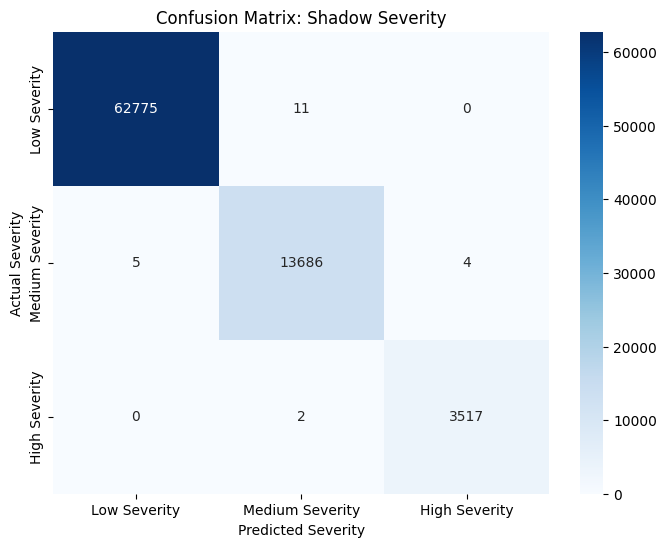

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score, classification_report

target_names = ['Low Severity', 'Medium Severity', 'High Severity']

#Basic Metrics
print("\n--- TASK 2: SEVERITY CLASSIFICATION RESULTS ---")
accuracy = accuracy_score(y_test['Severity_Label'], y_pred[:, 1])
balanced_acc = balanced_accuracy_score(y_test['Severity_Label'], y_pred[:, 1])
macro_f1 = f1_score(y_test['Severity_Label'], y_pred[:, 1], average='macro')

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test['Severity_Label'], y_pred[:, 1], target_names=target_names))

# Confusion Matrix Calculation
cm = confusion_matrix(y_test['Severity_Label'], y_pred[:, 1])

# Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix: Shadow Severity')
plt.ylabel('Actual Severity')
plt.xlabel('Predicted Severity')
plt.show()